In [1]:
# !pip install python-Levenshtein

In [2]:
import sys
import os
sys.path.append(os.path.abspath("../"))

# --- Imports ---
from transformers import T5Tokenizer, T5ForConditionalGeneration
from scripts.dataset.COGSDataset import COGSDataset
from scripts.util.constants import DEVICE, SAMPLE_SIZE
from scripts.util.getters import get_dataset_paths, get_results_path
from scripts.util.savers import save_model, save_predictions, save_metrics
from scripts.core.train import train
from scripts.core.test import test
from scripts.metrics.visuals import plot_metrics_table, plot_metrics_bar, compare_test_gen_metrics
from scripts.util.clear_memory import clear_memory

In [3]:
# --- Config ---
model_name = "t5-small"
enhancement = "srt"
inject_roles = True
role_flag = True

In [4]:
# --- Load tokenizer and model ---
tokenizer = T5Tokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(model_name).to(DEVICE)

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thouroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [5]:
# --- Load datasets ---
srl_paths = get_dataset_paths("srl")
srt_paths = get_dataset_paths("srt")

train_dataset = COGSDataset(srl_paths["train"], tokenizer, sample_frac=SAMPLE_SIZE, inject_roles=inject_roles, role_flag=role_flag)
dev_dataset   = COGSDataset(srl_paths["dev"], tokenizer, sample_frac=SAMPLE_SIZE, inject_roles=inject_roles, role_flag=role_flag)
test_dataset  = COGSDataset(srt_paths["test"], tokenizer, sample_frac=SAMPLE_SIZE, inject_roles=inject_roles, role_flag=False)
gen_dataset   = COGSDataset(srt_paths["gen"], tokenizer, sample_frac=SAMPLE_SIZE, inject_roles=inject_roles, role_flag=False)

In [6]:
# --- Train ---
model, tokenizer = train(model, tokenizer, train_dataset, dev_dataset, enhancement=enhancement, role_flag=role_flag)
save_model(model, tokenizer, model_name, enhancement)

Train Loss (Epoch 1): 0.7136
Dev Eval (Epoch 1):
  exact_match: 0.1253
  precision: 0.7557
  recall: 0.7267
  f1: 0.7277
  bleu: 0.6790
  edit_distance_avg: 52.7670
  predicate_accuracy: 0.8690
  valid_logical_form_ratio: 1.0000
Train Loss (Epoch 2): 0.1958
Dev Eval (Epoch 2):
  exact_match: 0.4230
  precision: 0.8800
  recall: 0.8861
  f1: 0.8798
  bleu: 0.8789
  edit_distance_avg: 22.3380
  predicate_accuracy: 0.9522
  valid_logical_form_ratio: 1.0000
Train Loss (Epoch 3): 0.1121
Dev Eval (Epoch 3):
  exact_match: 0.5820
  precision: 0.9309
  recall: 0.9355
  f1: 0.9319
  bleu: 0.9284
  edit_distance_avg: 11.4957
  predicate_accuracy: 0.9667
  valid_logical_form_ratio: 1.0000
Train Loss (Epoch 4): 0.0749
Dev Eval (Epoch 4):
  exact_match: 0.7563
  precision: 0.9718
  recall: 0.9728
  f1: 0.9715
  bleu: 0.9654
  edit_distance_avg: 5.3793
  predicate_accuracy: 0.9856
  valid_logical_form_ratio: 1.0000
Train Loss (Epoch 5): 0.0533
Dev Eval (Epoch 5):
  exact_match: 0.8560
  precision: 0

Predictions saved to: /notebooks/meta-semantic-research/predictions/srt/t5-small_test_predictions.txt
Metrics saved to: /notebooks/meta-semantic-research/results/srt/t5-small_test_metrics.csv
Test Eval:
  exact_match: 0.0000
  precision: 0.0000
  recall: 0.0000
  f1: 0.0000
  bleu: 0.0012
  edit_distance_avg: 105.5087
  predicate_accuracy: 0.0143
  valid_logical_form_ratio: 0.9847


,exact_match,precision,recall,f1,bleu,edit_distance_avg,predicate_accuracy,valid_logical_form_ratio
0,0.00%,0.00%,0.00%,0.00%,0.12%,105.51,1.43%,98.47%


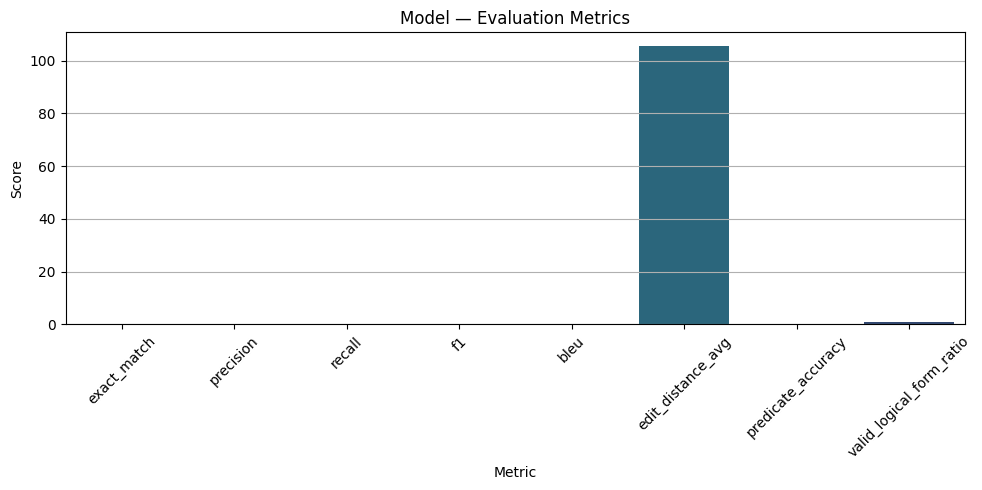

In [7]:
# --- Evaluate: Test ---
test_preds, test_metrics = test(model, tokenizer, test_dataset, model_name, enhancement, dataset_type="test")
plot_metrics_table(get_results_path(model_name, "test", enhancement))
plot_metrics_bar(get_results_path(model_name, "test", enhancement))

Predictions saved to: /notebooks/meta-semantic-research/predictions/srt/t5-small_gen_predictions.txt
Metrics saved to: /notebooks/meta-semantic-research/results/srt/t5-small_gen_metrics.csv
Gen Eval:
  exact_match: 0.0000
  precision: 0.0000
  recall: 0.0000
  f1: 0.0000
  bleu: 0.0009
  edit_distance_avg: 168.1333
  predicate_accuracy: 0.0227
  valid_logical_form_ratio: 0.9748


,exact_match,precision,recall,f1,bleu,edit_distance_avg,predicate_accuracy,valid_logical_form_ratio
0,0.00%,0.00%,0.00%,0.00%,0.09%,168.13,2.27%,97.48%


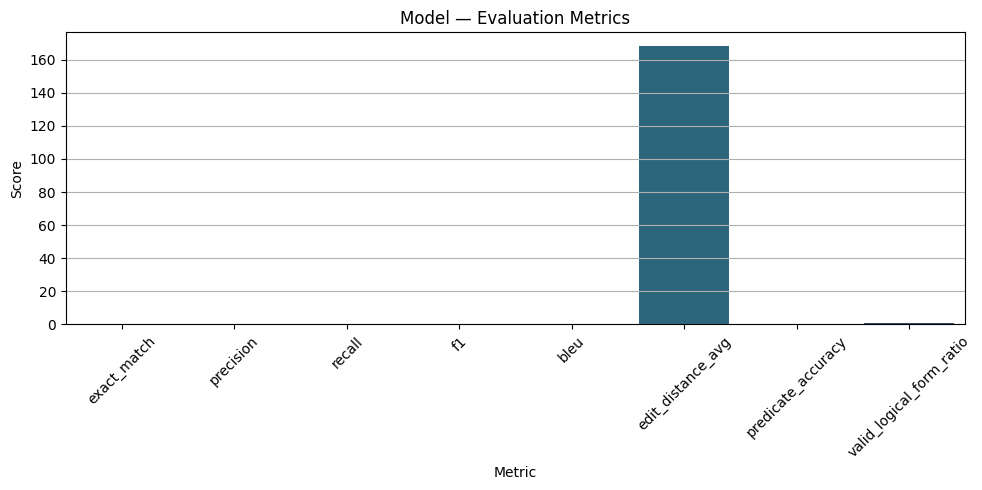

In [8]:
# --- Evaluate: Gen ---
gen_preds, gen_metrics = test(model, tokenizer, gen_dataset, model_name, enhancement, dataset_type="gen")
plot_metrics_table(get_results_path(model_name, "gen", enhancement))
plot_metrics_bar(get_results_path(model_name, "gen", enhancement))

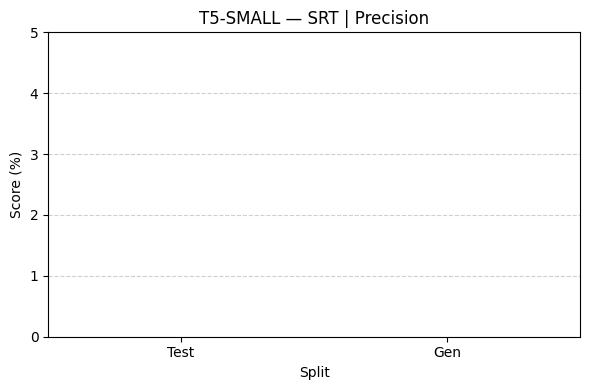

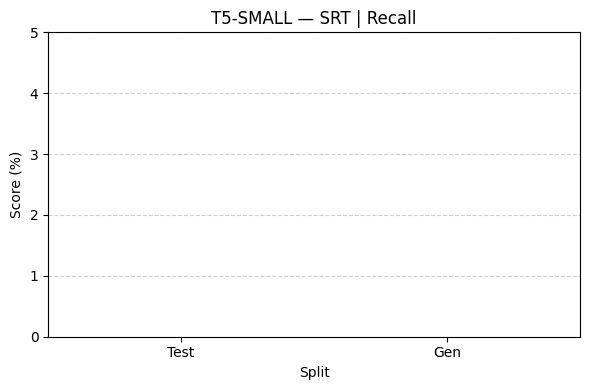

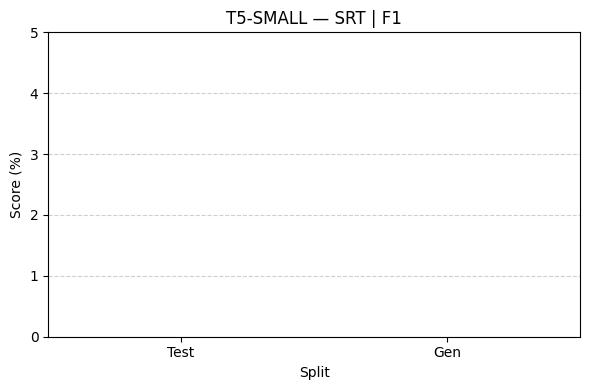

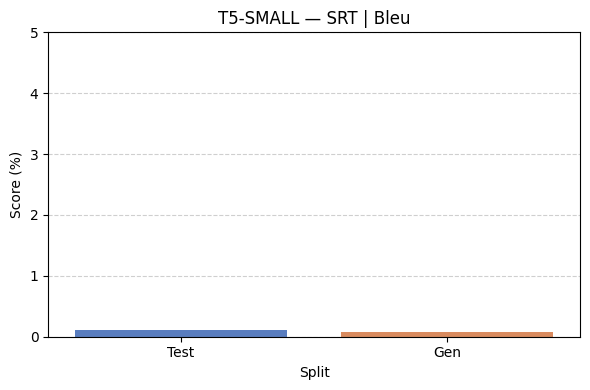

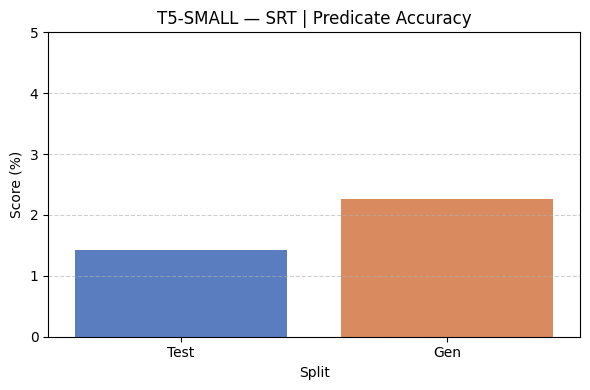

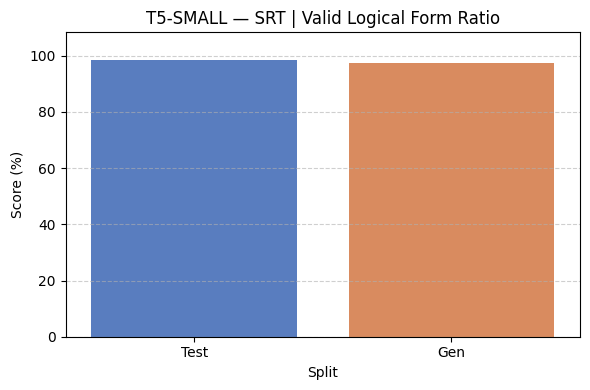

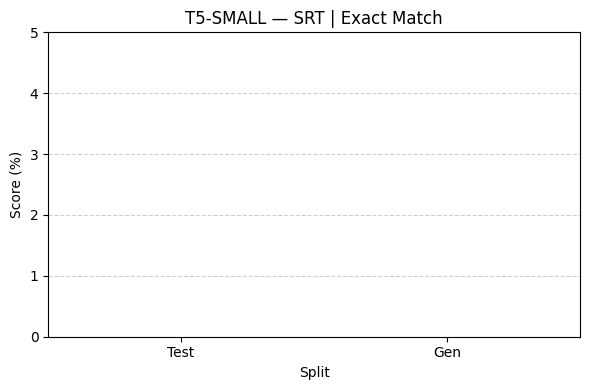

In [9]:
# --- Compare Test vs Gen Results
compare_test_gen_metrics(model_name, enhancement)

In [10]:
# --- Cleanup ---
clear_memory(model)